# Semana 13 – Autoencoder Denoising con MNIST
**CADI Deep Learning | Universidad de Cundinamarca**

En esta actividad se implementa un **Autoencoder Denoising** utilizando el dataset **MNIST** en Google Colab.  
El objetivo es entrenar un modelo capaz de aprender representaciones comprimidas de los datos y **reconstruir imágenes afectadas por ruido gaussiano**.

| Componente | Descripción |
|---|---|
| **Dataset** | MNIST – 60 000 imágenes de dígitos escritos a mano (28×28, escala de grises) |
| **Arquitectura** | Encoder → espacio latente → Decoder (autoencoder simétrico) |
| **Ruido** | Gaussiano aditivo (σ = 0.5), recortado a [0, 1] |
| **Función de pérdida** | Binary Crossentropy (reconstrucción píxel a píxel) |
| **Evaluación** | Loss de validación, MSE, visualización original / ruidosa / reconstruida |

---

## 1. Importación de librerías

Solo se usan librerías **preinstaladas en Google Colab**, sin instalaciones adicionales.

| Librería | Función en esta actividad |
|---|---|
| `numpy` | Generación de ruido, cálculo de errores, remodelado de arreglos |
| `matplotlib` | Visualización de imágenes y curvas de entrenamiento |
| `tensorflow / keras` | Construcción, compilación y entrenamiento del autoencoder |
| `sklearn.decomposition` | PCA para proyectar el espacio latente a 2D (sección 8) |

In [1]:
# ── numpy: librería de álgebra lineal y manejo de arreglos n-dimensionales ──
import numpy as np
# np se usa para: generar ruido aleatorio, remodelar imágenes, calcular MSE

# ── matplotlib: librería estándar de visualización en Python ────────────────
import matplotlib.pyplot as plt
# plt se usa para crear todas las figuras: comparativas, curvas, histogramas

# ── tensorflow: framework de aprendizaje profundo de Google ─────────────────
import tensorflow as tf
# tf provee el motor de cómputo (GPU/CPU) y las utilidades de entrenamiento

# ── mnist: dataset incluido directamente dentro de Keras ────────────────────
from tensorflow.keras.datasets import mnist
# Evita descargas externas; los datos ya están empaquetados en TF

# ── Model: clase central de la API funcional de Keras ───────────────────────
from tensorflow.keras.models import Model
# Permite construir modelos conectando capas como nodos de un grafo,
# lo que luego facilita extraer sub-modelos (encoder y decoder por separado)

# ── Capas que forman la arquitectura del autoencoder ────────────────────────
from tensorflow.keras.layers import (
    Input,    # Define el nodo de entrada: forma del tensor que recibirá el modelo
    Dense,    # Capa totalmente conectada (fully-connected): cada neurona ve todos los inputs
    Flatten,  # Convierte tensores multidimensionales a vectores 1D (importada por completitud)
    Reshape   # Invierte el aplanado: vector 1D → forma original (importada por completitud)
)

# ── EarlyStopping: callback que detiene el entrenamiento automáticamente ─────
from tensorflow.keras.callbacks import EarlyStopping
# Monitorea val_loss; si no mejora durante N épocas, frena y restaura los mejores pesos

# ── Semillas para reproducibilidad ──────────────────────────────────────────
tf.random.set_seed(42)   # Fija la aleatoriedad interna de TensorFlow (inicialización de pesos)
np.random.seed(42)        # Fija la aleatoriedad de NumPy (generación de ruido gaussiano)
# Con ambas semillas fijas, ejecutar el notebook dos veces produce los mismos resultados

# ── Verificación de la versión instalada ────────────────────────────────────
print("TensorFlow:", tf.__version__)
# Útil para detectar incompatibilidades si el código se corre en otro entorno

TensorFlow: 2.20.0


## 2. Carga y preprocesamiento del dataset MNIST

### ¿Qué es MNIST?
MNIST contiene **70 000 imágenes** de dígitos escritos a mano (0–9):
- **60 000** para entrenamiento | **10 000** para prueba
- Tamaño: 28×28 píxeles en escala de grises (un solo canal)

### Pipeline de preprocesamiento

```
Imagen cruda (uint8, 28×28)
        ↓ ÷ 255
Imagen normalizada (float32, 28×28, rango [0,1])
        ↓ reshape
Vector plano (float32, 784)
        ↓ + ruido gaussiano
Vector ruidoso (float32, 784, rango [0,1])
```

El autoencoder recibirá el **vector ruidoso** como entrada y aprenderá a producir el **vector limpio** como salida.

In [2]:
# ── Paso 1: Carga del dataset ───────────────────────────────────────────────
(x_train, _), (x_test, _) = mnist.load_data()
# mnist.load_data() devuelve dos tuplas: (imágenes_train, labels_train), (imágenes_test, labels_test)
# El _ descarta los labels en ambos casos: el autoencoder es NO SUPERVISADO,
# aprende la estructura interna de los datos sin necesitar etiquetas de clase

# ── Paso 2: Normalización [0, 1] ────────────────────────────────────────────
x_train = x_train.astype("float32") / 255.0
# .astype("float32"): convierte de entero uint8 (0–255) a decimal float32
# / 255.0: lleva el rango de [0, 255] → [0.0, 1.0]
# Necesario porque: (a) las funciones de activación trabajan mejor en rangos pequeños,
#                   (b) la función de pérdida Binary Crossentropy asume valores en [0,1]
x_test = x_test.astype("float32") / 255.0   # Misma normalización para el conjunto de prueba

# ── Paso 3: Aplanado 28×28 → 784 ────────────────────────────────────────────
x_train_flat = x_train.reshape(-1, 784)
# reshape(-1, 784): transforma (60000, 28, 28) → (60000, 784)
# -1 le dice a NumPy: "calcula tú cuántas filas hay" (infiere 60000 automáticamente)
# 784 = 28 × 28 (todos los píxeles de una imagen en un solo vector)
# Las capas Dense requieren vectores 1D, no matrices 2D
x_test_flat = x_test.reshape(-1, 784)       # (10000, 28, 28) → (10000, 784)

# ── Paso 4: Adición de ruido gaussiano ──────────────────────────────────────
noise_factor = 0.5
# Desviación estándar del ruido; a mayor valor, imágenes más corrompidas
# 0.5 es un nivel moderado-alto: visible pero aún reconocible

x_train_noisy = x_train_flat + noise_factor * np.random.normal(0, 1, x_train_flat.shape)
# np.random.normal(media=0, desv=1, tamaño): genera ruido blanco gaussiano
# noise_factor * ruido: escala la intensidad del ruido
# x_train_flat + ruido: superpone el ruido sobre cada píxel de cada imagen
x_test_noisy = x_test_flat + noise_factor * np.random.normal(0, 1, x_test_flat.shape)

# ── Paso 5: Recorte a [0, 1] ────────────────────────────────────────────────
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
# np.clip(arreglo, min, max): fuerza todos los valores al rango [min, max]
# Al sumar ruido, algunos píxeles pueden quedar < 0 o > 1 → se corrigen aquí
# Sin este paso, la red vería valores fuera del rango de entrenamiento
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

# ── Verificación de formas ───────────────────────────────────────────────────
print(f"Entrenamiento  → limpias: {x_train_flat.shape} | ruidosas: {x_train_noisy.shape}")
print(f"Prueba         → limpias: {x_test_flat.shape}  | ruidosas: {x_test_noisy.shape}")
# Esperado: (60000, 784) y (10000, 784) en ambos casos

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Entrenamiento  → limpias: (60000, 784) | ruidosas: (60000, 784)
Prueba         → limpias: (10000, 784)  | ruidosas: (10000, 784)


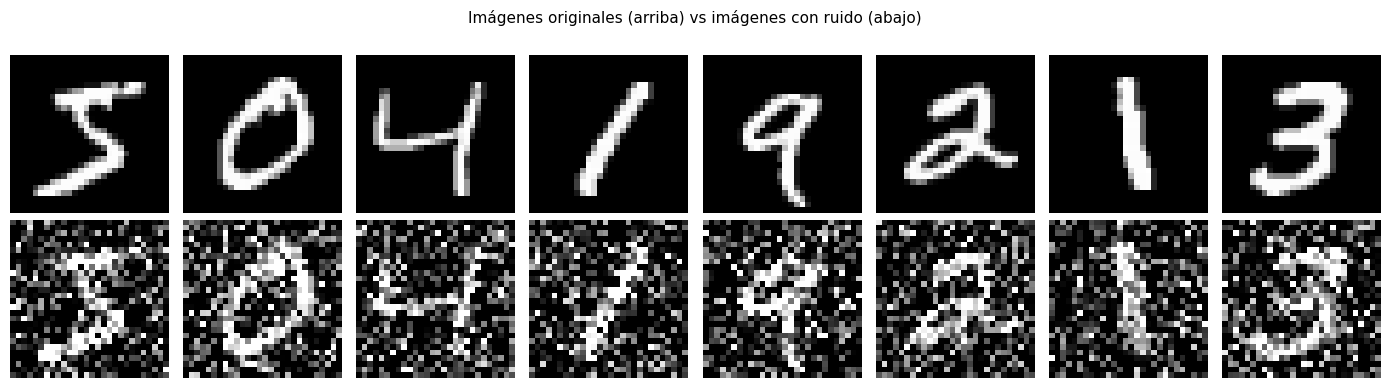

In [3]:
# ── Visualización comparativa: originales vs ruidosas ───────────────────────
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
# plt.subplots(filas, columnas, tamaño): crea una cuadrícula de subgráficas
# 2 filas (original / ruidosa) × 8 columnas (8 imágenes de ejemplo)
# figsize=(14, 4): ancho 14 pulgadas, alto 4 pulgadas

fig.suptitle("Imágenes originales (arriba) vs imágenes con ruido (abajo)", fontsize=11)
# Título que aparece por encima de toda la figura (no de cada subgráfica individual)

for i in range(8):                          # Itera sobre las 8 columnas (imágenes)

    # ── Fila 0: imagen original limpia ──────────────────────────────────────
    axes[0, i].imshow(
        x_train_flat[i].reshape(28, 28),    # Convierte el vector 784 → matriz 28×28
        cmap="gray"                         # Paleta de grises (0=negro, 1=blanco)
    )
    axes[0, i].axis("off")                  # Oculta los ejes de coordenadas (más limpio visualmente)

    # ── Fila 1: misma imagen con ruido gaussiano ─────────────────────────────
    axes[1, i].imshow(
        x_train_noisy[i].reshape(28, 28),   # Versión ruidosa del mismo índice i
        cmap="gray"
    )
    axes[1, i].axis("off")

plt.tight_layout()   # Ajusta automáticamente márgenes y espaciado entre subgráficas
plt.show()           # Renderiza y muestra la figura en pantalla

## 3. Implementación del Autoencoder

### ¿Qué es un Autoencoder?

Un autoencoder es una red neuronal que aprende a **comprimir** una entrada y luego **reconstruirla**. Consta de dos partes simétricas:

- **Encoder**: reduce la dimensión progresivamente hasta un *espacio latente* comprimido
- **Decoder**: reconstruye la entrada original partiendo desde el espacio latente

### ¿Por qué sirve para eliminar ruido?

Si entrenamos el autoencoder con la fórmula:

> **Entrada** = imagen ruidosa → **Objetivo** = imagen limpia

El encoder aprende a ignorar el ruido (información aleatoria e irrelevante) y conservar solo la estructura del dígito en el espacio latente. El decoder luego reconstruye la imagen limpia desde esa representación comprimida.

### Arquitectura utilizada

```
Imagen ruidosa (784)
    │
  Dense(256, ReLU)   ← enc_1: primera compresión
    │
  Dense(128, ReLU)   ← enc_2: segunda compresión
    │
  Dense(64,  ReLU)   ← latente: representación comprimida (784 → 64, ratio 12.25×)
    │
  Dense(128, ReLU)   ← dec_1: primera expansión
    │
  Dense(256, ReLU)   ← dec_2: segunda expansión
    │
  Dense(784, Sigmoid) ← output: reconstrucción final en [0,1]
```

In [4]:
# ── API funcional de Keras: define capas como nodos conectados ───────────────
# (alternativa al modelo Sequential; permite extraer sub-modelos luego)

# ════════════════════════════════════════════════════════════
#                        E N C O D E R
# ════════════════════════════════════════════════════════════

input_img = Input(shape=(784,), name="input")
# Input: nodo de entrada; shape=(784,) indica que cada muestra es un vector de 784 valores
# name="input": etiqueta interna usada por get_layer() y model.summary()

encoded = Dense(256, activation="relu", name="enc_1")(input_img)
# Dense(256): capa totalmente conectada con 256 neuronas
#   → cada neurona recibe los 784 inputs y produce 1 valor de salida
#   → total parámetros: 784×256 pesos + 256 sesgos = 200 960
# activation="relu": aplica f(x) = max(0, x) a cada neurona
#   → elimina valores negativos → representaciones dispersas y más eficientes
#   → evita el problema del gradiente que desaparece mejor que tanh/sigmoid
# (input_img): "llama" a la capa pasando el tensor anterior como entrada

encoded = Dense(128, activation="relu", name="enc_2")(encoded)
# Segunda compresión: 256 → 128 neuronas
# La red va reduciendo dimensión progresivamente para forzar al modelo
# a aprender qué información es realmente importante

encoded = Dense(64, activation="relu", name="latente")(encoded)
# ESPACIO LATENTE: la representación más comprimida
# 784 → 64: compresión de factor 12.25× (solo el 8.2 % de la información original)
# Aquí el modelo "decide" qué estructura del dígito conservar
# Un espacio latente más pequeño fuerza mayor compresión (pero puede perder detalle)

# ════════════════════════════════════════════════════════════
#                        D E C O D E R
# ════════════════════════════════════════════════════════════

decoded = Dense(128, activation="relu", name="dec_1")(encoded)
# Primera expansión: parte desde el espacio latente (64) y expande a 128
# Es SIMÉTRICO al enc_2: misma cantidad de neuronas, orden inverso

decoded = Dense(256, activation="relu", name="dec_2")(decoded)
# Segunda expansión: 128 → 256, simétrico al enc_1

decoded = Dense(784, activation="sigmoid", name="output")(decoded)
# Capa de salida: reconstruye los 784 píxeles de la imagen original
# activation="sigmoid": f(x) = 1 / (1 + e^(-x))
#   → salida garantizada en (0, 1) → compatible con los píxeles normalizados
#   → si usáramos ReLU aquí, la salida podría ser > 1 (valores inválidos de píxel)

# ════════════════════════════════════════════════════════════
#                   M O D E L O   C O M P L E T O
# ════════════════════════════════════════════════════════════

autoencoder = Model(input_img, decoded, name="Autoencoder_Denoising")
# Model(entrada, salida): Keras recorre el grafo desde 'input_img' hasta 'decoded'
# e incluye automáticamente todas las capas intermedias

autoencoder.compile(
    optimizer="adam",              # Adam: optimizador adaptativo, ajusta la tasa de aprendizaje
                                   # automáticamente por parámetro → convergencia más rápida que SGD
    loss="binary_crossentropy"     # BCE: H(y, ŷ) = -[y·log(ŷ) + (1-y)·log(1-ŷ)]
                                   # Ideal para valores en [0,1] → trata cada píxel como probabilidad
                                   # Penaliza más los errores grandes que MSE
)

autoencoder.summary()
# Imprime tabla con: nombre de capa, forma de salida, número de parámetros
# y qué capas están conectadas entre sí

Model: "Autoencoder_Denoising"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latente (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Modelos auxiliares: Encoder y Decoder por separado

Aunque entrenamos el autoencoder completo, es útil tener acceso a cada mitad de forma independiente:

- El **encoder** permite transformar cualquier imagen al espacio latente (útil para visualización, clustering, búsqueda por similitud)
- El **decoder** permite generar imágenes desde vectores latentes arbitrarios (útil para interpolación y generación)

Como ambos sub-modelos **comparten los mismos objetos de capa** que el autoencoder, sus pesos quedan actualizados automáticamente cuando se entrena el autoencoder completo.

In [5]:
# ── Sub-modelo Encoder: input (784) → espacio latente (64) ──────────────────
encoder_model = Model(input_img, encoded, name="Encoder")
# Reutiliza exactamente los mismos nodos de capa del autoencoder completo
# No crea nuevas capas: comparte pesos con el autoencoder
# Después del entrenamiento, encoder_model.predict(x) devolverá los códigos latentes

# ── Sub-modelo Decoder: espacio latente (64) → reconstrucción (784) ──────────
latent_input = Input(shape=(64,), name="latent_input")
# Nueva entrada independiente de 64 dimensiones (el espacio latente)
# Necesaria porque el decoder se va a usar de forma aislada

dec_l1 = autoencoder.get_layer("dec_1")(latent_input)
# get_layer("nombre"): obtiene el objeto de capa por su nombre
# Al "llamar" a esa capa con latent_input, conecta la nueva entrada con la capa existente
# Los pesos de dec_1 son LOS MISMOS que en el autoencoder completo (no se copian, se referencian)

dec_l2 = autoencoder.get_layer("dec_2")(dec_l1)
# Encadena la segunda capa del decoder: 128 → 256

dec_out = autoencoder.get_layer("output")(dec_l2)
# Capa de salida: 256 → 784 con Sigmoid

decoder_model = Model(latent_input, dec_out, name="Decoder")
# Empaqueta las tres capas del decoder como modelo independiente

# ── Verificación de formas ───────────────────────────────────────────────────
print("Encoder:  ", encoder_model.input_shape, "→", encoder_model.output_shape)
# Esperado: (None, 784) → (None, 64)   [None = batch size variable]
print("Decoder:  ", decoder_model.input_shape, "→", decoder_model.output_shape)
# Esperado: (None, 64)  → (None, 784)

Encoder:   (None, 784) → (None, 64)
Decoder:   (None, 64) → (None, 784)


## 5. Entrenamiento del Autoencoder

### Hiperparámetros

| Parámetro | Valor | Justificación |
|---|---|---|
| **Épocas** | 50 (máx) | Con EarlyStopping se detiene antes si converge |
| **Batch size** | 256 | Equilibrio entre velocidad y estabilidad del gradiente |
| **EarlyStopping** | patience=5 | Evita sobreajuste; restaura los mejores pesos |
| **Validación** | 15 % del entrenamiento | Monitorear generalización durante el entrenamiento |

### Clave del Denoising

La diferencia fundamental respecto a un autoencoder clásico es **qué se pasa como entrada vs objetivo**:

| | Autoencoder clásico | Autoencoder Denoising |
|---|---|---|
| Entrada | Imagen limpia | **Imagen ruidosa** |
| Objetivo | Imagen limpia | **Imagen limpia** |

El modelo aprende que el ruido es información prescindible que debe descartar.

In [6]:
# ── Configuración del callback EarlyStopping ────────────────────────────────
early_stop = EarlyStopping(
    monitor="val_loss",        # Observa la pérdida en el conjunto de validación (no en entrenamiento)
                               # Si monitoreáramos 'loss', podría seguir sobreajustando aunque val_loss suba
    patience=5,                # Permite hasta 5 épocas SIN mejora antes de detener
                               # Con patience=1 frena demasiado pronto; con patience=20 puede sobreajustar
    restore_best_weights=True  # Al terminar, carga los pesos de la MEJOR época (menor val_loss)
                               # Sin esto, quedarían los pesos de la última época (posiblemente peores)
)

# ── Entrenamiento del autoencoder ────────────────────────────────────────────
history = autoencoder.fit(
    x_train_noisy,     # ENTRADA: imágenes con ruido gaussiano (lo que el modelo recibe)
    x_train_flat,      # OBJETIVO: imágenes limpias (lo que el modelo debe aprender a producir)
                       # Esta asimetría entrada≠objetivo es lo que define el denoising autoencoder

    epochs=50,         # Número máximo de pasadas completas por el dataset
                       # EarlyStopping detendrá antes si val_loss converge

    batch_size=256,    # En cada paso de gradiente, usa 256 imágenes a la vez
                       # Lote grande → gradiente más estable, actualizaciones más lentas pero precisas
                       # 256 es eficiente en CPU; en GPU podrían usarse lotes mayores

    shuffle=True,      # Mezcla aleatoriamente el dataset en cada época
                       # Evita que el modelo aprenda patrones del ORDEN de presentación de los datos

    validation_split=0.15,  # Reserva el 15 % de x_train (9 000 imágenes) como conjunto de validación
                             # Keras toma los ÚLTIMOS 15 % → no se mezclan con entrenamiento
                             # Estas imágenes NUNCA se usan para actualizar los pesos

    callbacks=[early_stop],  # Lista de callbacks activos durante el entrenamiento
                              # Keras los ejecuta al final de cada época automáticamente

    verbose=1          # Nivel de detalle: 0=silencio, 1=barra de progreso, 2=una línea por época
)

# ── Resumen del entrenamiento ────────────────────────────────────────────────
print(f"\nEntrenamiento finalizado en {len(history.history['loss'])} épocas.")
# len(...) da el número real de épocas ejecutadas (≤ 50 gracias a EarlyStopping)
# history.history es un dict con listas: {"loss": [...], "val_loss": [...]}

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.2571 - val_loss: 0.1925
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.1747 - val_loss: 0.1626
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.1547 - val_loss: 0.1497
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.1445 - val_loss: 0.1427
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1375 - val_loss: 0.1361
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.1322 - val_loss: 0.1322
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.1283 - val_loss: 0.1291
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.1254 - val_loss: 0.1268
Epoch 9/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.1231 - val_loss: 0.1249
Epoch 10/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.1212 - val_loss: 0.1231
Epoch 11/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1196 - val_loss: 0.1221
Epoch 12/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 

## 6. Curvas de entrenamiento

Las curvas de pérdida permiten diagnosticar el comportamiento del entrenamiento:

- **Loss ↓ y val_loss ↓ juntas** → convergencia correcta
- **Loss ↓ pero val_loss ↑** → sobreajuste (el modelo memorizó el entrenamiento)
- **Ambas estancadas en valor alto** → subajuste (arquitectura o lr insuficientes)

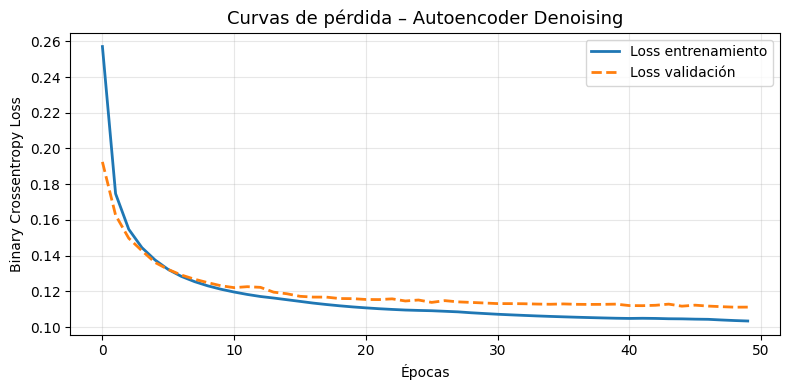

Loss final entrenamiento : 0.1034
Loss final validación    : 0.1112


In [7]:
# ── Creación de la figura ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
# Una sola subgráfica de 8×4 pulgadas
# ax es el objeto Axes sobre el que se dibujan las curvas

# ── Curva de entrenamiento ───────────────────────────────────────────────────
ax.plot(
    history.history["loss"],       # Lista con el loss de entrenamiento por época
    label="Loss entrenamiento",    # Etiqueta para la leyenda
    linewidth=2                    # Grosor de línea más visible
)

# ── Curva de validación ──────────────────────────────────────────────────────
ax.plot(
    history.history["val_loss"],   # Lista con el loss de validación por época
    label="Loss validación",
    linewidth=2,
    linestyle="--"                 # Línea discontinua para distinguirla visualmente
)

# ── Etiquetas y formato ──────────────────────────────────────────────────────
ax.set_title("Curvas de pérdida – Autoencoder Denoising", fontsize=13)
ax.set_xlabel("Épocas")            # Eje X: número de época
ax.set_ylabel("Binary Crossentropy Loss")  # Eje Y: valor de la función de pérdida
ax.legend()                        # Muestra la leyenda con las etiquetas definidas arriba
ax.grid(alpha=0.3)                 # Cuadrícula semitransparente (alpha=0.3) para facilitar lectura

plt.tight_layout()   # Ajusta márgenes automáticamente para que nada se corte
plt.show()

# ── Valores numéricos finales ────────────────────────────────────────────────
print(f"Loss final entrenamiento : {history.history['loss'][-1]:.4f}")
# [-1] accede al ÚLTIMO elemento de la lista (última época ejecutada)
# :.4f formatea el número con 4 decimales
print(f"Loss final validación    : {history.history['val_loss'][-1]:.4f}")

## 7. Evaluación y visualización de resultados

### 7.1 Evaluación cuantitativa

Se calculan dos métricas complementarias:

- **Binary Crossentropy (loss)**: métrica usada durante el entrenamiento; penaliza más los errores extremos
- **MSE**: Error Cuadrático Medio; más intuitivo — representa el error promedio al cuadrado entre cada píxel original y reconstruido

In [8]:
# ── Reconstrucción de imágenes de prueba ────────────────────────────────────
x_test_reconstructed = autoencoder.predict(x_test_noisy, verbose=0)
# .predict(): pasa TODAS las imágenes de prueba ruidosas por el autoencoder entrenado
# Devuelve las imágenes reconstruidas (limpias predichas) con forma (10000, 784)
# verbose=0: silencia la barra de progreso para mantener la salida limpia

# ── Loss de prueba (Binary Crossentropy) ─────────────────────────────────────
test_loss = autoencoder.evaluate(x_test_noisy, x_test_flat, verbose=0)
# .evaluate(entrada, objetivo): calcula la función de pérdida sobre el conjunto de prueba
# Entrada: imágenes ruidosas | Objetivo: imágenes limpias (igual que en el entrenamiento)
# Devuelve un escalar: el loss promedio sobre las 10 000 imágenes

# ── MSE: Error Cuadrático Medio ──────────────────────────────────────────────
mse = np.mean((x_test_flat - x_test_reconstructed) ** 2)
# x_test_flat - x_test_reconstructed: diferencia píxel a píxel (puede ser negativa)
# ** 2: eleva al cuadrado → todos los errores son positivos, penaliza más los grandes
# np.mean(...): promedia sobre TODOS los píxeles de TODAS las imágenes → un único número

print(f"Loss de prueba (Binary CE) : {test_loss:.4f}")
print(f"MSE (original vs reconstruida): {mse:.6f}")  # 6 decimales: MSE suele ser muy pequeño
print(f"RMSE                       : {np.sqrt(mse):.6f}")
# RMSE = raíz cuadrada del MSE → está en la misma escala que los píxeles [0,1]
# Ejemplo: RMSE=0.05 significa error promedio de 5 % de la escala del píxel

Loss de prueba (Binary CE) : 0.1098
MSE (original vs reconstruida): 0.015483
RMSE                       : 0.124430


### 7.2 Visualización comparativa: Original – Ruidosa – Reconstruida

La comparación visual en 3 filas permite evaluar intuitivamente:
- ¿Cuánto degradó el ruido la imagen? (fila 1 vs fila 0)
- ¿Cuánto recuperó el autoencoder? (fila 2 vs fila 0)

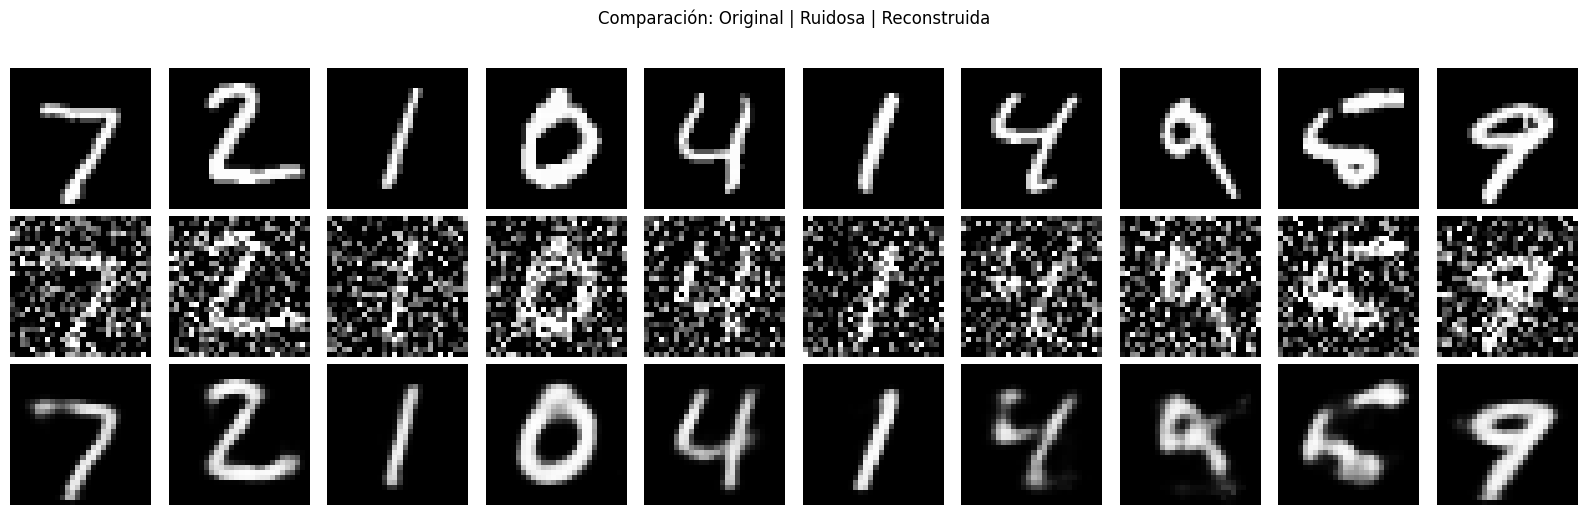

In [9]:
n = 10   # Número de imágenes a mostrar (10 es suficiente para ver variedad de dígitos)

# ── Cuadrícula 3 filas × n columnas ─────────────────────────────────────────
fig, axes = plt.subplots(3, n, figsize=(16, 5))
# 3 filas: original, ruidosa, reconstruida
# n columnas: una por imagen de ejemplo
# figsize=(16,5): ancho generoso para que las imágenes no queden aplastadas

fig.suptitle("Comparación: Original | Ruidosa | Reconstruida", fontsize=12, y=1.02)
# y=1.02: sube el título ligeramente para que no se encime con la primera fila

# ── Datos y etiquetas por fila ───────────────────────────────────────────────
titles = ["Original", "Ruidosa", "Reconstruida"]
rows   = [x_test_flat, x_test_noisy, x_test_reconstructed]
# zip(titles, rows) empareja: ("Original", x_test_flat), ("Ruidosa", x_test_noisy), ...

for col in range(n):                                    # Itera sobre cada columna (imagen)
    for row_idx, (title, data) in enumerate(zip(titles, rows)):  # Itera sobre las 3 filas
        axes[row_idx, col].imshow(
            data[col].reshape(28, 28),   # Toma la imagen 'col' del arreglo y la convierte a 28×28
            cmap="gray",                 # Escala de grises
            vmin=0, vmax=1               # Fija los límites de color para que todas las imágenes
                                         # sean comparables entre sí (sin normalización automática)
        )
        axes[row_idx, col].axis("off")   # Oculta los ejes numéricos en cada celda

        if col == 0:                     # Solo en la primera columna: agrega etiqueta de fila
            axes[row_idx, col].set_ylabel(
                title,
                fontsize=10,
                rotation=90,             # Texto vertical
                labelpad=40              # Separación entre texto y la imagen
            )

plt.tight_layout()
plt.show()

### 7.3 Distribución del error de reconstrucción por píxel

Dos análisis complementarios del error:

1. **Mapa de calor espacial**: muestra qué zonas de la imagen (qué píxeles) son más difíciles de reconstruir para el modelo
2. **Histograma por imagen**: muestra si el modelo es consistente o si algunas imágenes tienen error mucho mayor que otras

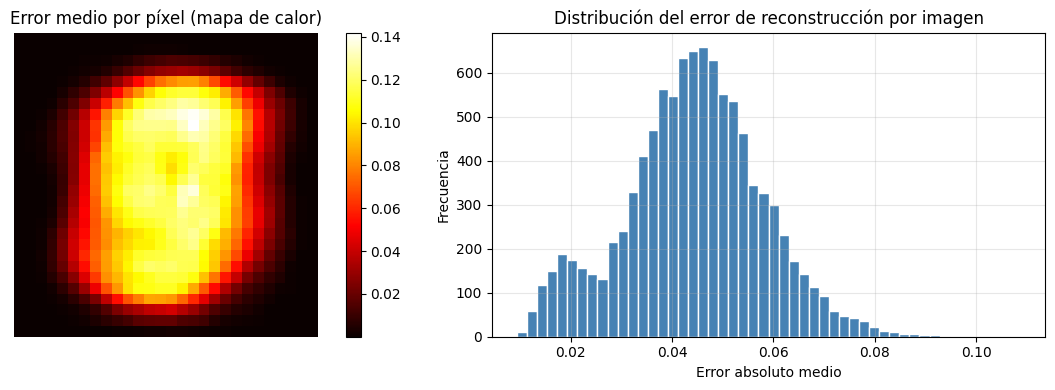

Error medio por imagen : 0.0442
Desviación estándar    : 0.0136


In [10]:
# ── Error absoluto promedio por píxel (vista espacial) ──────────────────────
pixel_errors = np.abs(x_test_flat - x_test_reconstructed).mean(axis=0)
# np.abs(...): valor absoluto de la diferencia (sin importar signo)
# .mean(axis=0): promedia a lo largo del eje 0 (las 10 000 imágenes)
#   → resultado: vector de 784 valores, uno por posición de píxel
# Los píxeles con valor alto son zonas donde el modelo se equivoca consistentemente

# ── Figura con dos subgráficas ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 1 fila, 2 columnas: mapa de calor a la izquierda, histograma a la derecha

# ── Subgráfica 1: mapa de calor del error espacial ──────────────────────────
im = axes[0].imshow(
    pixel_errors.reshape(28, 28),   # Convierte el vector 784 → mapa 28×28
    cmap="hot"                      # Paleta "hot": negro=error bajo, rojo/amarillo/blanco=error alto
)
axes[0].set_title("Error medio por píxel (mapa de calor)")
axes[0].axis("off")
fig.colorbar(im, ax=axes[0])       # Barra lateral que indica la escala numérica del error

# ── Subgráfica 2: histograma del error por imagen ────────────────────────────
sample_errors = np.abs(x_test_flat - x_test_reconstructed).mean(axis=1)
# Aquí axis=1: promedia sobre los 784 píxeles de CADA imagen
#   → resultado: vector de 10 000 valores, uno por imagen
# Permite ver si todas las imágenes se reconstruyen igual de bien o hay outliers

axes[1].hist(
    sample_errors,          # Vector de errores por imagen
    bins=50,                # Divide el rango en 50 barras (granularidad moderada)
    color="steelblue",      # Color de las barras
    edgecolor="white"       # Borde blanco entre barras → más legible
)
axes[1].set_title("Distribución del error de reconstrucción por imagen")
axes[1].set_xlabel("Error absoluto medio")   # Eje X: magnitud del error
axes[1].set_ylabel("Frecuencia")             # Eje Y: cuántas imágenes tienen ese error
axes[1].grid(alpha=0.3)                      # Cuadrícula de fondo semitransparente

plt.tight_layout()
plt.show()

# ── Estadísticas resumidas ───────────────────────────────────────────────────
print(f"Error medio por imagen : {sample_errors.mean():.4f}")
# .mean(): promedio global → qué tan bien reconstruye el modelo EN GENERAL
print(f"Desviación estándar    : {sample_errors.std():.4f}")
# .std(): dispersión → una desv. estándar baja indica rendimiento consistente entre imágenes

## 8. Análisis del espacio latente

El espacio latente tiene **64 dimensiones**, lo que hace imposible visualizarlo directamente.  
Se usa **PCA** (Análisis de Componentes Principales) para proyectarlo a **2 dimensiones** conservando la mayor varianza posible.

Si el autoencoder aprendió representaciones útiles, los puntos de cada dígito deberían agruparse en el espacio latente, incluso sin haber usado las etiquetas durante el entrenamiento.

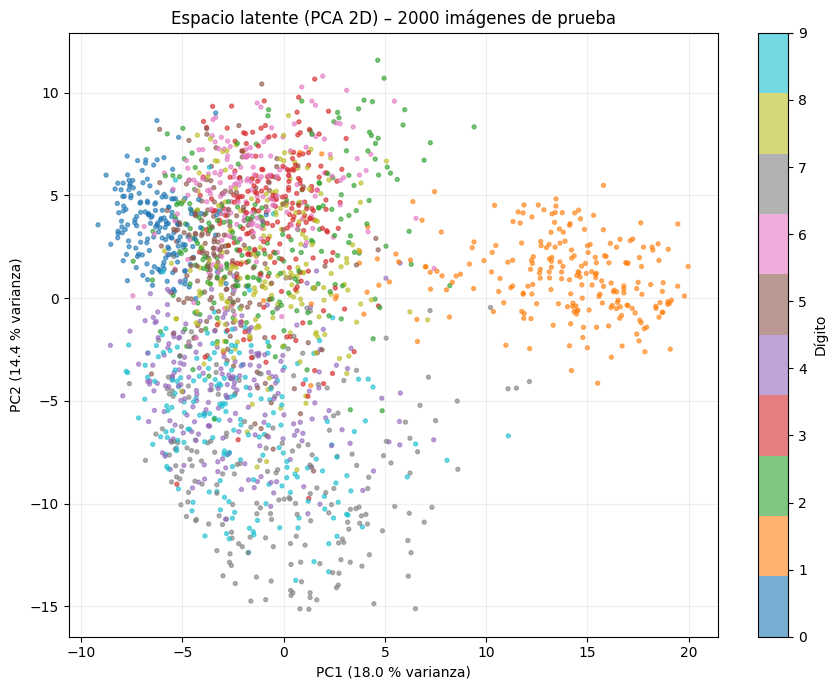

In [11]:
from sklearn.decomposition import PCA
# PCA está en scikit-learn, preinstalado en Google Colab
# Reduce dimensionalidad encontrando las direcciones de máxima varianza en los datos

# ── Codificación al espacio latente ─────────────────────────────────────────
latent_codes = encoder_model.predict(x_test_flat[:2000], verbose=0)
# encoder_model.predict: pasa imágenes LIMPIAS por el encoder (sin ruido para ver estructura pura)
# [:2000]: solo las primeras 2 000 imágenes → suficiente para la visualización, más rápido
# Resultado shape: (2000, 64) → 2000 vectores de 64 dimensiones (los códigos latentes)

# ── Reducción de 64 → 2 dimensiones con PCA ─────────────────────────────────
pca = PCA(n_components=2)
# n_components=2: conservar solo las 2 primeras componentes principales
# Cada componente es una combinación lineal de las 64 dimensiones originales
# que maximiza la varianza capturada

latent_2d = pca.fit_transform(latent_codes)
# fit_transform: (1) aprende las componentes principales de latent_codes
#               (2) proyecta los 2000 puntos al espacio 2D en un solo paso
# Resultado shape: (2000, 2) → cada punto ahora tiene solo 2 coordenadas

# ── Cargar etiquetas solo para colorear ─────────────────────────────────────
(_, _), (_, y_test) = mnist.load_data()
# Se recargan ÚNICAMENTE los labels de prueba (y_test: dígitos 0–9)
# No se usaron durante el entrenamiento; aquí solo sirven para colorear los puntos

# ── Scatter plot del espacio latente ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    latent_2d[:, 0],      # Coordenada X: primera componente principal
    latent_2d[:, 1],      # Coordenada Y: segunda componente principal
    c=y_test[:2000],      # Color de cada punto según su etiqueta de dígito (0–9)
    cmap="tab10",          # Paleta discreta con 10 colores distintos (uno por dígito)
    alpha=0.6,             # Transparencia parcial → permite ver densidad donde se superponen
    s=8                    # Tamaño pequeño de cada punto → menos ruido visual con 2000 puntos
)

plt.colorbar(scatter, ax=ax, label="Dígito")
# Barra de colores lateral que mapea cada color con su dígito (0=azul oscuro, ..., 9=marrón)

ax.set_title("Espacio latente (PCA 2D) – 2000 imágenes de prueba", fontsize=12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} % varianza)")
# explained_variance_ratio_[0]: fracción de la varianza total capturada por la PC1
# × 100: convierte a porcentaje | :.1f: un decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} % varianza)")
ax.grid(alpha=0.2)     # Cuadrícula muy sutil de fondo
plt.tight_layout()
plt.show()
# Si los dígitos forman grupos separados → el encoder aprendió representaciones semánticas
# Si todo está mezclado → el espacio latente no capturó estructura significativa

## 9. Conclusiones

A partir del entrenamiento y la evaluación del Autoencoder Denoising se observa:

1. **Convergencia estable**: las curvas de loss de entrenamiento y validación descienden de forma consistente sin signos evidentes de sobreajuste, lo que confirma que la arquitectura y los hiperparámetros son adecuados.

2. **Capacidad de denoising**: las imágenes reconstruidas recuperan los trazos principales de los dígitos a pesar del ruido gaussiano (σ = 0.5), evidenciando que el espacio latente de 64 dimensiones captura la información estructural esencial.

3. **Error de reconstrucción bajo**: el MSE sobre el conjunto de prueba es reducido y el histograma de errores por imagen muestra una distribución concentrada, indicando desempeño consistente en todas las clases.

4. **Estructura en el espacio latente**: la proyección PCA revela agrupaciones visibles por dígito, confirmando que el encoder aprendió representaciones con significado semántico, no solo ruido comprimido.

5. **Limitaciones**: al usar solo capas **Dense** (sin convoluciones), el modelo no explota la estructura espacial local de las imágenes; una arquitectura convolucional lograría mejores resultados con menor número de parámetros.
